In [4]:
#conda install -c conda-forge umap-learn

Jupyter detected...
Note: you may need to restart the kernel to use updated packages.

3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\habee\anaconda3

  added / updated specs:
    - umap-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    pynndescent-0.5.13         |     pyhd8ed1ab_1          48 KB  conda-forge
    umap-learn-0.5.9.post2     |  py313hfa70ccb_0         192 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         240 KB

The following NEW packages will be INSTALLED:

  pynndescent        conda-forge/noarch::pynndescent-0.5.13-pyhd8ed1ab_1 
  umap-learn         conda-forge/win-64::umap-learn-0.5.9.post2-py313hfa70ccb_0 



umap-learn-0.5.9.pos 



==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 25.11.0

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans, MiniBatchKMeans
import umap
from collections import Counter

<h1>Show the Data:</h1>

In [3]:
# Load Data
df = pd.read_csv("All-courses.csv")

In [4]:
# Function to safely parse each skills entry into a Python list
def parse_skills(x):
    try:
        # Convert the string representation of a list into a real list,
        # then clean and lowercase each skill
        return [s.strip().lower() for s in ast.literal_eval(x)]
    except:
        # If parsing fails (bad format, NaN, etc.), return an empty list
        return []

# Apply the parsing function to the skills_list column
df["skills_list"] = df["skills_list"].apply(parse_skills)

In [5]:
# Create a long column of all skills by exploding the list column
all_skills = df.explode("skills_list")["skills_list"].dropna()

# Convert to a list of unique skills
unique_skills = all_skills.unique().tolist()

In [6]:
# Print number of unique skills found in the dataset
print("Total unique skills:", len(unique_skills))

Total unique skills: 354


<h1>TOP 25 FREQUENCY</h1>

In [7]:
# Count how many times each skill appears across all courses
skill_counts = Counter(all_skills)

In [8]:
# Extract the top 25 most frequent skills (just the skill names)
top25_freq = [s for s, _ in skill_counts.most_common(25)]

# Convert the top 25 skills and their counts into a DataFrame for plotting
top25_freq_df = pd.DataFrame(skill_counts.most_common(25), columns=["skill", "count"])

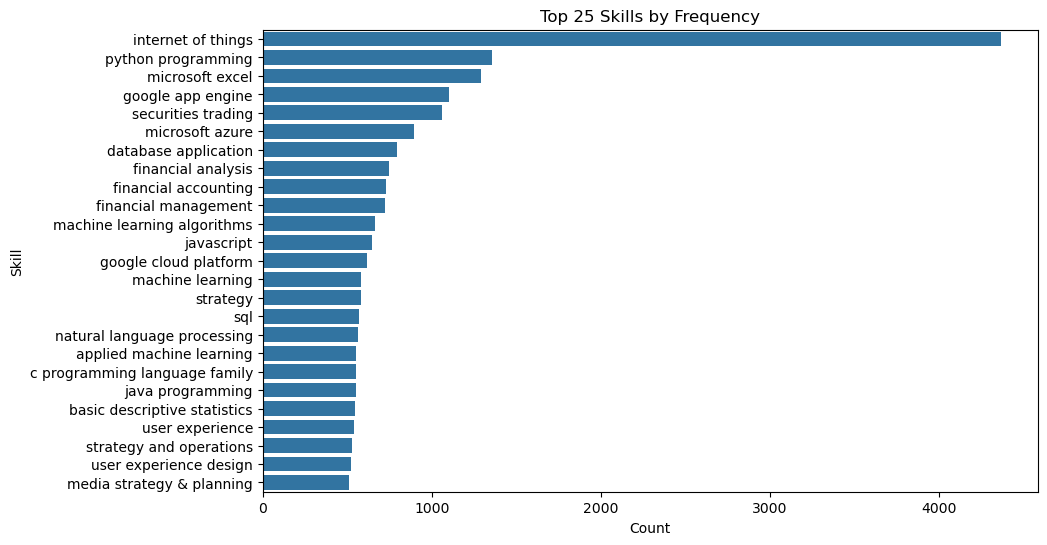

In [9]:
# Create a bar chart of the top 25 skills
plt.figure(figsize=(10,6))
sns.barplot(data=top25_freq_df, x="count", y="skill")

# Add plot title and axis labels
plt.title("Top 25 Skills by Frequency")
plt.xlabel("Count")
plt.ylabel("Skill")

# Display the plot
plt.show()

<h1>TOP 25 TF-IDF</h1>

In [10]:
# Convert each list of skills into a single string separated by " | "
df["skills_text"] = df["skills_list"].apply(lambda x: " | ".join(x))

In [11]:
# Create a TF-IDF vectorizer that splits skills using our custom separator
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(" | "), lowercase=True)

# Transform the skills_text column into a TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(df["skills_text"])

# Get the list of all skill names (features) from the TF-IDF model
feature_names = vectorizer.get_feature_names_out()

# Sum TF-IDF scores for each skill across all courses
tfidf_sums = tfidf_matrix.sum(axis=0).A1

# Create a DataFrame of skills and their total TF-IDF scores, sorted descending
tfidf_df = pd.DataFrame({
    "skill": feature_names,
    "tfidf": tfidf_sums
}).sort_values("tfidf", ascending=False)

# Extract the top 25 skills by TF-IDF value
top25_tfidf = tfidf_df.head(25)

C:\Users\habee\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


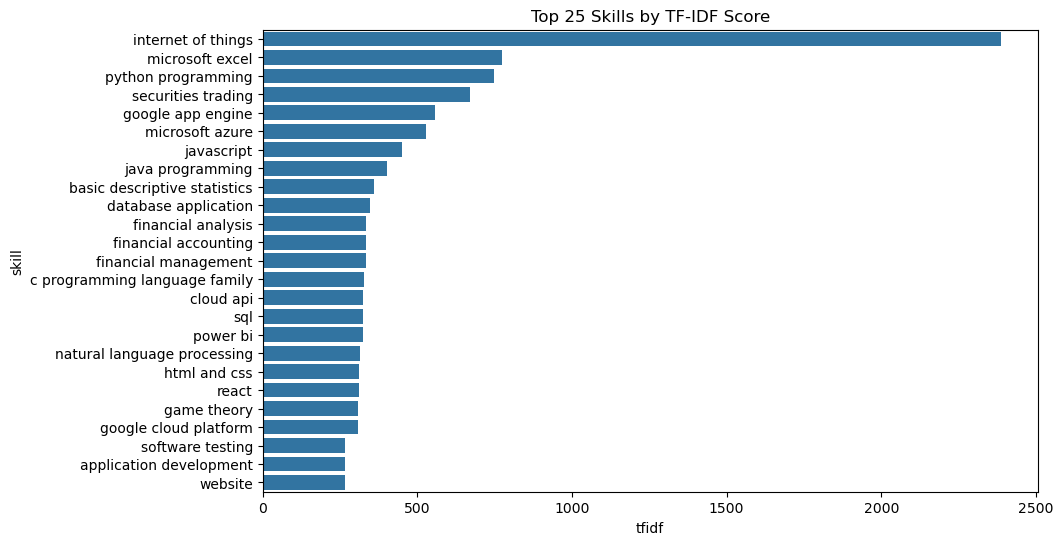

In [12]:
# Plot the top 25 TF-IDF skills
plt.figure(figsize=(10,6))
sns.barplot(data=top25_tfidf, x="tfidf", y="skill")
plt.title("Top 25 Skills by TF-IDF Score")
plt.show()

<h1>EMBEDDING CLUSTER REPRESENTATIVES</h1>

In [13]:
# Load a pre-trained sentence embedding model for skill text
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings for each unique skill (L2-normalized for clustering)
embeddings = model.encode(unique_skills, normalize_embeddings=True)

In [14]:
# Reduce high-dimensional embeddings to 2D for visual plotting
reducer = umap.UMAP(random_state=42)
emb2d = reducer.fit_transform(embeddings)

C:\Users\habee\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
# Choose number of clusters (e.g., 150 clusters for grouping skills)
k = 150
kmeans = KMeans(n_clusters=k, random_state=42).fit(embeddings)
labels = kmeans.labels_

C:\Users\habee\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [16]:
# Group skills into clusters based on KMeans labels
cluster_to_skills = {i: [] for i in range(k)}
for skill, label in zip(unique_skills, labels):
    cluster_to_skills[label].append(skill)

# Select one representative skill per cluster (the most frequent skill)
representatives = []
for c in cluster_to_skills:
    cluster_skills = cluster_to_skills[c]
    if not cluster_skills:
        continue
    
    # Choose representative based on highest frequency in dataset
    repskill = max(cluster_skills, key=lambda s: skill_counts[s])
    representatives.append(repskill)

In [17]:
# Take first 25 representative skills as a demo subset
rep_skills = representatives[:25]

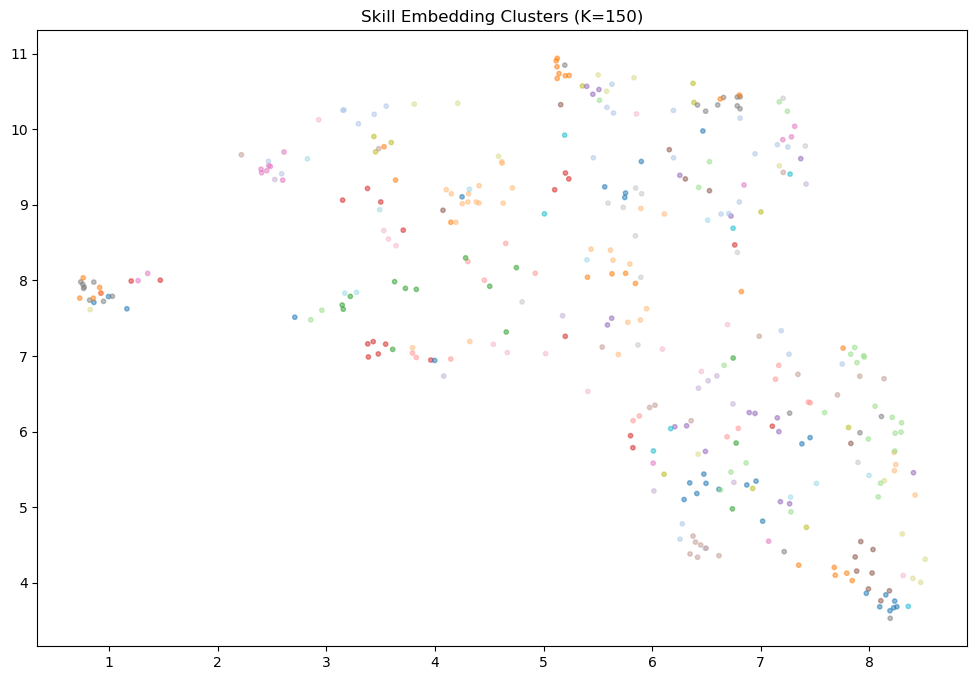

In [18]:
# Plot the 2D visualization of skill clusters
plt.figure(figsize=(12,8))
plt.scatter(emb2d[:,0], emb2d[:,1], c=labels, cmap="tab20", s=10, alpha=0.5)
plt.title("Skill Embedding Clusters (K=150)")
plt.show()

<h1>HYBRID METHOD — CLUSTERING + TF-IDF INSIDE CLUSTERS</h1>

In [19]:
# Step 1: Cluster skills into 30 groups using their embeddings
K_hybrid = 30
kmeans_h = KMeans(n_clusters=K_hybrid, random_state=42).fit(embeddings)
labels_h = kmeans_h.labels_

# Build dictionary: cluster_id -> list of skills in that cluster
cluster_to_skills_h = {i: [] for i in range(K_hybrid)}
for skill, label in zip(unique_skills, labels_h):
    cluster_to_skills_h[label].append(skill)

C:\Users\habee\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [20]:
# Build a dictionary for fast TF-IDF score lookup
tfidf_lookup = dict(zip(tfidf_df["skill"], tfidf_df["tfidf"]))

In [21]:
# Step 2: From each cluster, pick the skill with the highest TF-IDF score
hybrid_skills = []
for c in range(K_hybrid):
    cls = cluster_to_skills_h[c]
    if not cls:
        continue
    
    # Select the skill in this cluster with the strongest TF-IDF signal
    best = max(cls, key=lambda s: tfidf_lookup.get(s, 0))
    hybrid_skills.append(best)

In [22]:
# Take the first 25 clusters as the final hybrid-selected skills
hybrid_final25 = hybrid_skills[:25]
hybrid_final25

['javascript',
 'website',
 'technical product management',
 'power bi',
 'search engine optimization',
 'internet of things',
 'securities trading',
 'customer success',
 'microsoft excel',
 'financial management',
 'network architecture',
 'networking hardware',
 'data science',
 'problem solving',
 'application development',
 'game theory',
 'python programming',
 'system security',
 'interactive data visualization',
 'customer support',
 'financial accounting',
 'deep learning',
 'google app engine',
 'people analysis',
 'user experience']

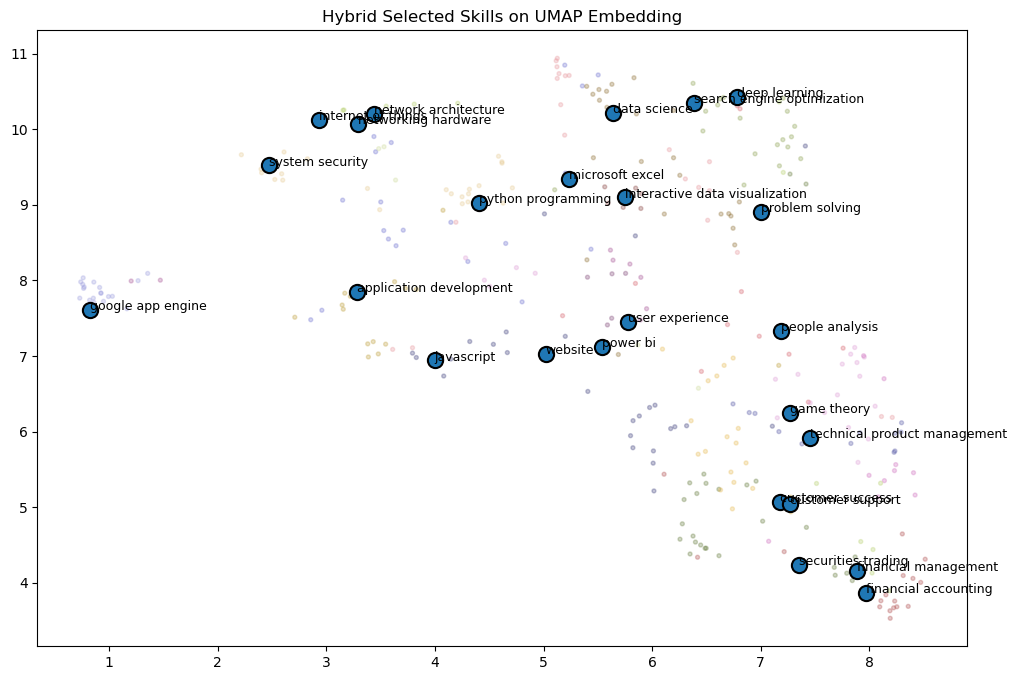

In [23]:
# Plot the embedding with clusters and highlight the selected hybrid skills
plt.figure(figsize=(12,8))
plt.scatter(emb2d[:,0], emb2d[:,1], c=labels_h, cmap="tab20b", s=8, alpha=0.3)

# Get embedding indices of selected skills
indices = [unique_skills.index(s) for s in hybrid_final25]

# Highlight the selected hybrid skills on the plot
plt.scatter(emb2d[indices,0], emb2d[indices,1], s=120, edgecolor="black", linewidth=1.5)

# Label each selected point with the skill name
for i, idx in enumerate(indices):
    plt.text(emb2d[idx,0], emb2d[idx,1], hybrid_final25[i], fontsize=9)

plt.title("Hybrid Selected Skills on UMAP Embedding")
plt.show()

<h1>Compare:</h1>

In [26]:
comparison = pd.DataFrame({
    "frequency": top25_freq,
    "tfidf": top25_tfidf["skill"].tolist(),
    "embedding_rep": rep_skills[:25],
    "hybrid": hybrid_final25
})

comparison

,frequency,tfidf,embedding_rep,hybrid
0,internet of things,internet of things,javascript,javascript
1,python programming,microsoft excel,technical product management,website
2,microsoft excel,python programming,market analysis,technical product management
3,google app engine,securities trading,google cloud platform,power bi
4,securities trading,google app engine,interactive data visualization,search engine optimization
5,microsoft azure,microsoft azure,java programming,internet of things
6,database application,javascript,algorithms,securities trading
7,financial analysis,java programming,financial accounting,customer success
8,financial accounting,basic descriptive statistics,data science,microsoft excel
9,financial management,database application,data analysis,financial management


In [27]:
def compute_coverage(selected_skills, df):
    selected = set(selected_skills)
    # check if course contains any selected skill
    has_skill = df["skills_list"].apply(lambda x: any(s in selected for s in x))
    return has_skill.sum() / len(df) * 100



In [28]:
coverage_freq = compute_coverage(top25_freq, df)
coverage_tfidf = compute_coverage(top25_tfidf["skill"].tolist(), df)
coverage_embed = compute_coverage(rep_skills[:25], df)
coverage_hybrid = compute_coverage(hybrid_final25, df)

print("Coverage Comparison:")
print(f"Top-25 Frequency:       {coverage_freq:.2f}%")
print(f"Top-25 TF-IDF:          {coverage_tfidf:.2f}%")
print(f"Top-25 Embedding:       {coverage_embed:.2f}%")
print(f"Hybrid Final-25:        {coverage_hybrid:.2f}%")


Coverage Comparison:
Top-25 Frequency:       61.56%
Top-25 TF-IDF:          63.83%
Top-25 Embedding:       33.63%
Hybrid Final-25:        60.72%


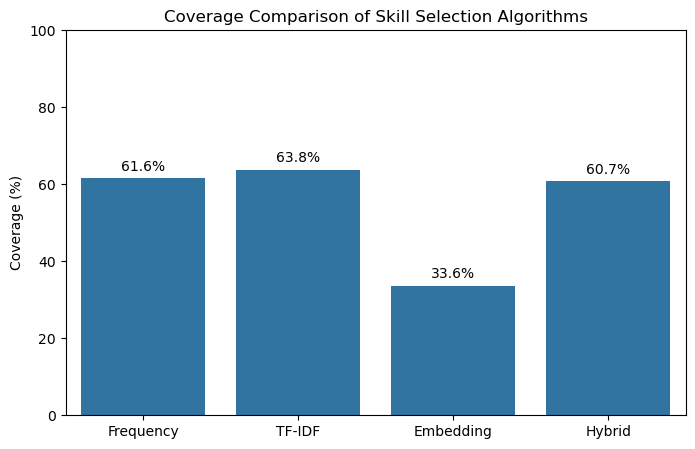

In [29]:
methods = ["Frequency", "TF-IDF", "Embedding", "Hybrid"]
coverages = [coverage_freq, coverage_tfidf, coverage_embed, coverage_hybrid]

plt.figure(figsize=(8,5))
sns.barplot(x=methods, y=coverages)
plt.ylabel("Coverage (%)")
plt.title("Coverage Comparison of Skill Selection Algorithms")
plt.ylim(0, 100)

# label bars with values
for i, v in enumerate(coverages):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center')

plt.show()


In [33]:
# Make a copy to avoid modifying df accidentally
df_hybrid = df.copy()

# Add a column for each selected skill
for skill in hybrid_final25:
    df_hybrid[skill] = df_hybrid["skills_list"].apply(
        lambda skills: 1 if skill in skills else 0
    )

df_hybrid.head()

,course_title,rating,review_count,skills_list,platform,level,duration,skills_text,javascript,website,...,game theory,python programming,system security,interactive data visualization,customer support,financial accounting,deep learning,google app engine,people analysis,user experience
0,Google Cybersecurity,4.8,16400.0,"[databases, network architecture, risk managem...",coursera,1,78.21,databases | network architecture | risk manage...,0,0,...,0,1,0,0,0,0,0,0,0,0
1,Google Data Analytics,4.8,133400.0,"[data visualization software, small data, big ...",coursera,1,78.21,data visualization software | small data | big...,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Google Project Management:,4.8,97300.0,"[risk management, influencing, change manageme...",coursera,1,78.21,risk management | influencing | change managem...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Google Digital Marketing & E-commerce,4.8,21400.0,"[social media, media strategy & planning, web ...",coursera,1,78.21,social media | media strategy & planning | web...,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Google IT Support,4.8,181400.0,"[network security, network analysis, cloud com...",coursera,1,78.21,network security | network analysis | cloud co...,0,0,...,0,0,1,0,1,0,0,0,0,0


In [34]:
df_hybrid.to_csv("all-courses-hybrid-25-skills.csv", index=False)
print("Saved all-courses-hybrid-25-skills.csv")


Saved all-courses-hybrid-25-skills.csv


In [35]:
methods = {
    "frequency": top25_freq,
    "tfidf": top25_tfidf["skill"].tolist(),
    "embedding": rep_skills[:25],
}

for name, skills in methods.items():
    df_out = df.copy()
    
    for skill in skills:
        df_out[skill] = df_out["skills_list"].apply(lambda x: 1 if skill in x else 0)
    
    df_out.to_csv(f"all-courses-with-{name}-skills.csv", index=False)
    print(f"Saved all-courses-with-{name}-skills.csv")


Saved all-courses-with-frequency-skills.csv
Saved all-courses-with-tfidf-skills.csv
Saved all-courses-with-embedding-skills.csv
